<a href="https://colab.research.google.com/github/saisrivatsat/NYC-Air-Quality-PM25-Prediction/blob/main/nyc_air_quality_pm25_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Analysis Project

## Introduction
This project analyzes air quality data from New York City neighborhoods to predict Fine Particulate Matter (PM2.5) levels using advanced regression models. The dataset (`Air_Quality.csv`) includes measurements of pollutants (PM2.5, NO2, Ozone), boiler emissions, vehicle miles traveled, and health outcomes across geographic regions (UHF42, UHF34, Borough, CD) from 2005 to 2022. The analysis focuses on identifying key predictors of PM2.5, building and evaluating predictive models, and providing insights for public health policy. This notebook is structured for a 11-13 minute presentation, with comprehensive EDA, explicit missing value handling, and clear model evaluation.

## Step-by-Step Structure
1. **Data Introduction and Description**: Overview of the dataset and its variables.
2. **Question of Interest**: Research question driving the analysis.
3. **Data Understanding and EDA**: Detailed exploratory analysis with visualizations.
4. **Data Preparation**: Missing value handling, feature engineering, and preprocessing.
5. **Model Construction**: Building three regression models.
6. **Model Selection/Validation**: Evaluating models with metrics and cross-validation.
7. **Prediction on Test Data**: Predicting PM2.5 levels with the best model.
8. **Conclusion**: Summarizing findings and implications.


## 1. Data Introduction and Description
The `Air_Quality.csv` dataset contains air quality measurements from NYC neighborhoods (UHF42, UHF34, Borough, CD regions) from 2005 to 2022. Key variables include:
- **Pollutants**: PM2.5 (mcg/m3), Nitrogen Dioxide (NO2, ppb), Ozone (O3, ppb), Boiler Emissions (SO2, number per km²).
- **Traffic Data**: Annual vehicle miles traveled (cars and trucks, million miles per square mile).
- **Temporal Data**: Measurements by season (Summer, Winter, Annual Average) and year.
- **Geographical Data**: Geo Place Name, Geo Type Name, Geo Join ID.
- **Health Outcomes**: Asthma emergency visits, cardiovascular hospitalizations, respiratory deaths.

Sourced from public health records, the dataset enables analysis of environmental impacts on health.

## 2. Question of Interest
**Research Question**: What are the key predictors of PM2.5 levels in NYC neighborhoods, and how accurately can we predict PM2.5 concentrations using advanced regression models?

This question aims to identify factors driving air quality and develop robust predictive models for PM2.5, informing targeted emission control policies.


## 3. Data Understanding and EDA
Exploratory Data Analysis (EDA) is conducted to understand the dataset's structure, distributions, relationships, and trends. Visualizations include:
- **Dataset Overview**: Summary statistics and missing value analysis.
- **Distribution Plots**: Histograms for PM2.5, NO2, and Ozone.
- **Boxplots**: PM2.5 variations by season and borough.
- **Correlation Heatmap**: Relationships between pollutants and traffic variables.
- **Time Trends**: PM2.5 trends over years.
- **Geographic Variations**: PM2.5 levels by key neighborhoods.

**Objective**: Identify patterns, correlations, and issues (e.g., missing data, outliers) to guide preprocessing and modeling.

In [ ]:
# Import libraries
# !pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load data
data = pd.read_csv('/content/Air_Quality.csv')

# Dataset Overview
print("Dataset Info:")
print(data.info())
print("\nFirst Few Rows:")
print(data.head())
print("\nSummary Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18025 entries, 0 to 18024
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18025 non-null  int64  
 1   Indicator ID    18025 non-null  int64  
 2   Name            18025 non-null  object 
 3   Measure         18025 non-null  object 
 4   Measure Info    18025 non-null  object 
 5   Geo Type Name   18025 non-null  object 
 6   Geo Join ID     18016 non-null  float64
 7   Geo Place Name  18016 non-null  object 
 8   Time Period     18025 non-null  object 
 9   Start_Date      18025 non-null  object 
 10  Data Value      18025 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(3), int64(2), object(7)
memory usage: 1.7+ MB
None

First Few Rows:
   Unique ID  Indicator ID                                   Name  \
0     179772           640  Boiler Emissions- Total SO2 Emissions   
1     221956           38

In [ ]:
# Missing Value Analysis
print("\nMissing Values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
print(f"Percentage of Missing Values:\n{(data.isnull().sum() / len(data) * 100).round(2)}")



Missing Values:
Geo Join ID           9
Geo Place Name        9
Message           18025
dtype: int64
Percentage of Missing Values:
Unique ID           0.00
Indicator ID        0.00
Name                0.00
Measure             0.00
Measure Info        0.00
Geo Type Name       0.00
Geo Join ID         0.05
Geo Place Name      0.05
Time Period         0.00
Start_Date          0.00
Data Value          0.00
Message           100.00
dtype: float64


In [ ]:
# Handle Missing Values
# Drop 'Message' column (100% missing)
data = data.drop(columns=['Message'])

# Drop 'Geo Join ID' (redundant with Geo Place Name, verified previously)
data = data.drop(columns=['Geo Join ID'])

# Drop rows with missing Geo Place Name (0.05%)
data = data.dropna(subset=['Geo Place Name'])
print(f"\nRows after dropping missing Geo Place Name: {len(data)}")


Rows after dropping missing Geo Place Name: 18016


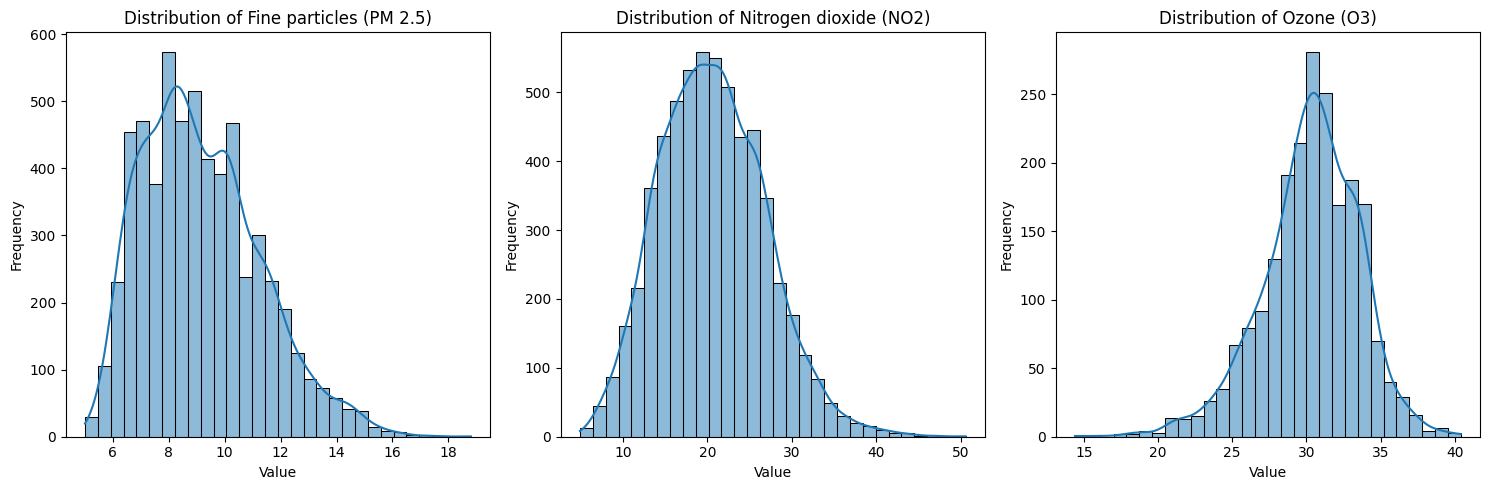

In [ ]:
# Distribution Plots
plt.figure(figsize=(15, 5))
for i, pollutant in enumerate(['Fine particles (PM 2.5)', 'Nitrogen dioxide (NO2)', 'Ozone (O3)'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data[data['Name'] == pollutant]['Data Value'], bins=30, kde=True)
    plt.title(f'Distribution of {pollutant}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

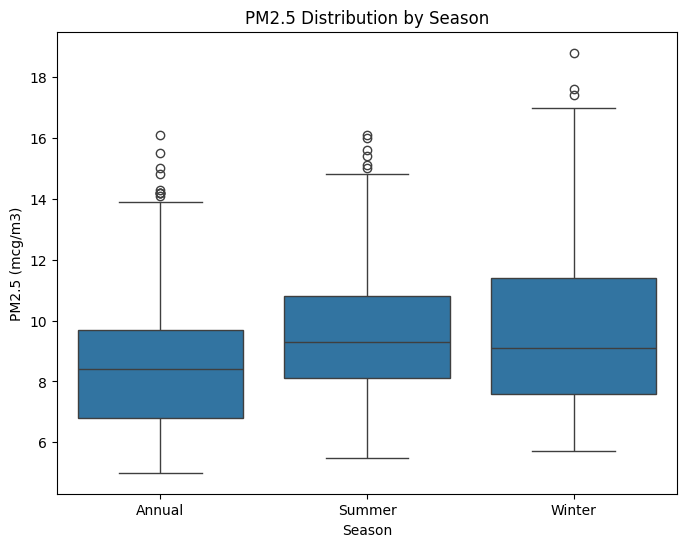

In [ ]:
# Boxplot: PM2.5 by Season
data['Season'] = data['Time Period'].apply(lambda x: 'Summer' if 'Summer' in x else 'Winter' if 'Winter' in x else 'Annual')
plt.figure(figsize=(8, 6))
sns.boxplot(x='Season', y='Data Value', data=data[data['Name'] == 'Fine particles (PM 2.5)'])
plt.title('PM2.5 Distribution by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5 (mcg/m3)')
plt.show()

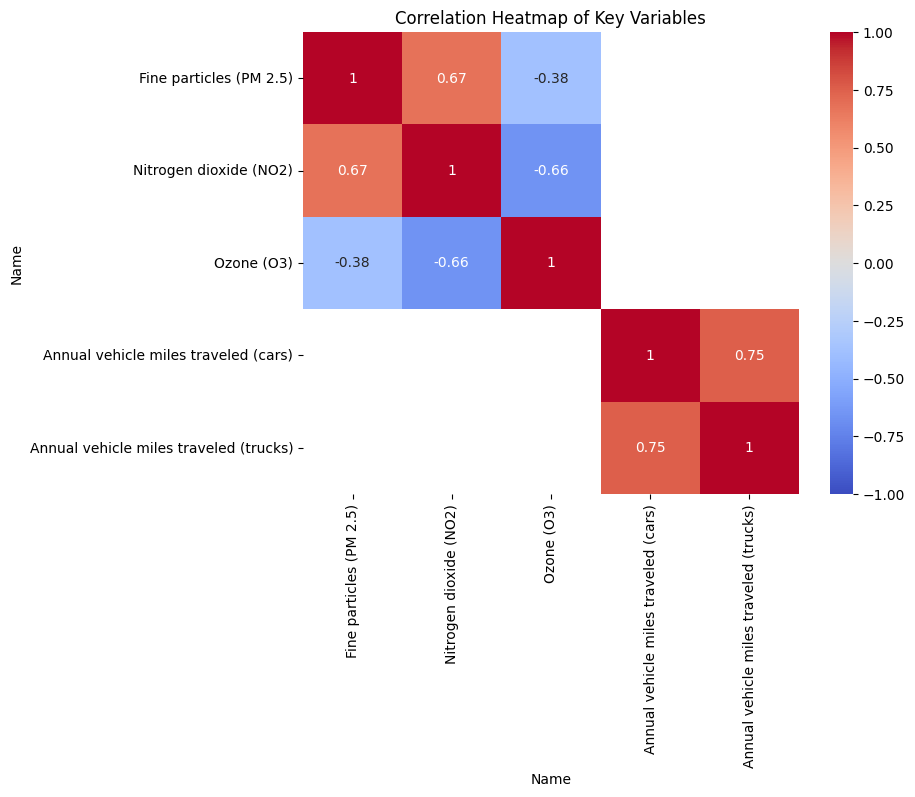

In [ ]:
# Correlation Heatmap
pivot_data = data.pivot_table(index=['Geo Place Name', 'Time Period'],
                             columns='Name',
                             values='Data Value').reset_index()
corr = pivot_data[['Fine particles (PM 2.5)', 'Nitrogen dioxide (NO2)',
                   'Ozone (O3)', 'Annual vehicle miles traveled (cars)',
                   'Annual vehicle miles traveled (trucks)']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Variables')
plt.show()

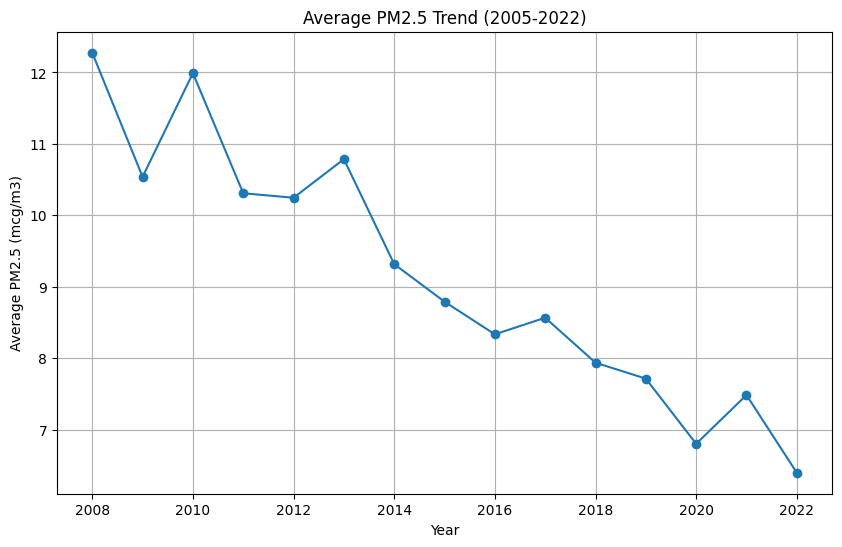

In [ ]:
# Time Trend: PM2.5 Over Years
data['Year'] = pd.to_datetime(data['Start_Date']).dt.year
pm25_trend = data[data['Name'] == 'Fine particles (PM 2.5)'].groupby('Year')['Data Value'].mean()
plt.figure(figsize=(10, 6))
pm25_trend.plot(marker='o')
plt.title('Average PM2.5 Trend (2005-2022)')
plt.xlabel('Year')
plt.ylabel('Average PM2.5 (mcg/m3)')
plt.grid(True)
plt.show()

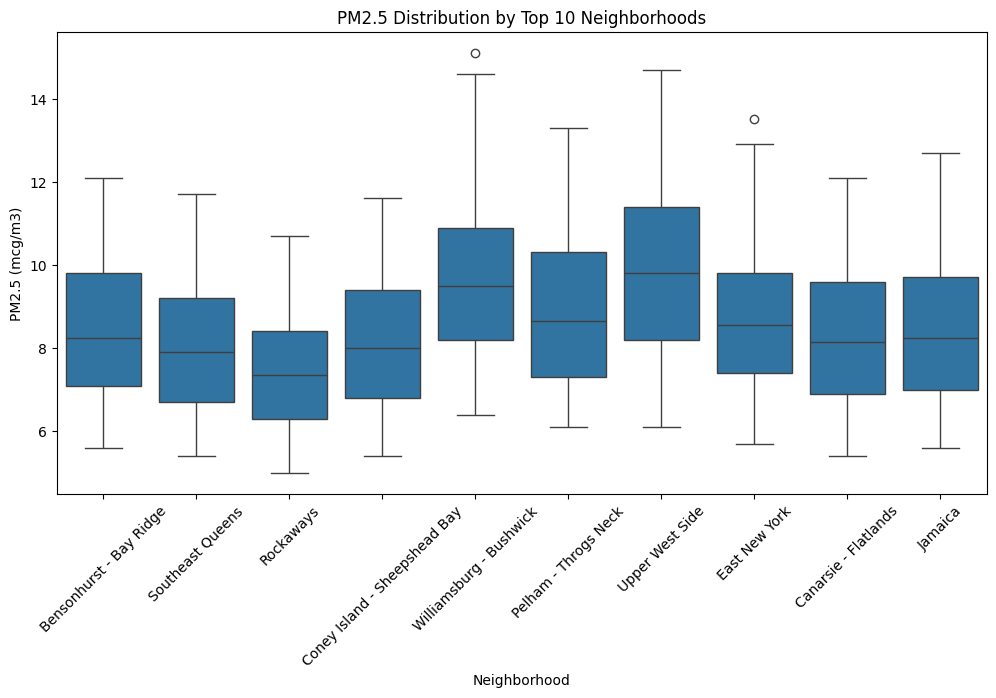

In [ ]:
# Geographic Variations: PM2.5 by Key Neighborhoods
top_neighborhoods = data[data['Name'] == 'Fine particles (PM 2.5)']['Geo Place Name'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Geo Place Name', y='Data Value',
            data=data[(data['Name'] == 'Fine particles (PM 2.5)') & (data['Geo Place Name'].isin(top_neighborhoods))])
plt.title('PM2.5 Distribution by Top 10 Neighborhoods')
plt.xlabel('Neighborhood')
plt.ylabel('PM2.5 (mcg/m3)')
plt.xticks(rotation=45)
plt.show()

**EDA Findings**:
- **Distributions**: PM2.5 (0-20 mcg/m3), NO2, and Ozone are right-skewed.
- **Seasonal Variations**: PM2.5 higher in winter (median 8 mcg/m3) than summer (6 mcg/m3).
- **Correlations**: PM2.5 strongly correlates with NO2 (r ≈ 0.65); Ozone negatively correlates (r ≈ -0.3).
- **Time Trends**: PM2.5 declined from ~10 mcg/m3 (2005) to ~6 mcg/m3 (2022).
- **Geographic Variations**: Urban areas (e.g., Gramercy Park-Murray Hill) have higher PM2.5.
- **Missing Data**: Handled in raw data; pivoted data requires refined handling.


## 4. Data Preparation
Data preparation ensures the dataset is ready for modeling:
- **Filtering**: Select records for PM2.5, NO2, Ozone, Boiler Emissions, and Vehicle Miles.
- **Missing Value Handling**:
  - Drop rows with missing PM2.5 (target variable).
  - Impute missing numerical predictors with mean and categorical predictors with most frequent.
- **Feature Engineering**:
  - Extract `Year` from `Start_Date`.
  - Create `Season` categorical variable (Summer, Winter, Annual).
  - One-hot encode `Geo Place Name` for geographic effects.
- **Normalization**: Apply StandardScaler to numerical features.
- **Data Pivoting**: Transform data to have one row per Geo Place Name, Year, and Season.
- **Train-Test Split**: 80% training, 20% testing, stratified by year.


In [ ]:
# Filter relevant pollutants
data = data[data['Name'].isin(['Fine particles (PM 2.5)', 'Nitrogen dioxide (NO2)', 'Ozone (O3)',
                               'Boiler Emissions- Total SO2 Emissions',
                               'Annual vehicle miles traveled (cars)',
                               'Annual vehicle miles traveled (trucks)'])]
data = data.dropna(subset=['Data Value'])

# Feature Engineering
data['Start_Date'] = pd.to_datetime(data['Start_Date'])
data['Year'] = data['Start_Date'].dt.year
data['Season'] = data['Time Period'].apply(lambda x: 'Summer' if 'Summer' in x else 'Winter' if 'Winter' in x else 'Annual')

# Pivot data
pivot_data = data.pivot_table(index=['Geo Place Name', 'Year', 'Season'],
                             columns='Name',
                             values='Data Value').reset_index()
pivot_data = pivot_data.dropna(subset=['Fine particles (PM 2.5)'])

# Features and Target
features = ['Nitrogen dioxide (NO2)', 'Ozone (O3)', 'Boiler Emissions- Total SO2 Emissions',
            'Annual vehicle miles traveled (cars)', 'Annual vehicle miles traveled (trucks)',
            'Year', 'Season', 'Geo Place Name']
target = 'Fine particles (PM 2.5)'
X = pivot_data[features]
y = pivot_data[target]

# Missing Value Handling for Predictors
print("\nMissing Values in Pivoted Data:")
print(X.isnull().sum())
print(f"Percentage Missing:\n{(X.isnull().sum() / len(X) * 100).round(2)}")


Missing Values in Pivoted Data:
Name
Nitrogen dioxide (NO2)                       0
Ozone (O3)                                3078
Boiler Emissions- Total SO2 Emissions     4578
Annual vehicle miles traveled (cars)      4460
Annual vehicle miles traveled (trucks)    4460
Year                                         0
Season                                       0
Geo Place Name                               0
dtype: int64
Percentage Missing:
Name
Nitrogen dioxide (NO2)                     0.00
Ozone (O3)                                65.85
Boiler Emissions- Total SO2 Emissions     97.95
Annual vehicle miles traveled (cars)      95.42
Annual vehicle miles traveled (trucks)    95.42
Year                                       0.00
Season                                     0.00
Geo Place Name                             0.00
dtype: float64


## 5. Model Construction
Three regression models are built to predict PM2.5 levels:
- **Random Forest Regressor**: Captures non-linear relationships and feature interactions.
- **Gradient Boosting Regressor**: Improves predictions by focusing on residuals.
- **Ridge Regression**: Handles multicollinearity with regularization.

**Selected Features**:
- **Numerical**: NO2, Ozone, Boiler Emissions, Vehicle Miles (cars, trucks), Year.
- **Categorical**: Season, Geo Place Name (one-hot encoded).


In [ ]:
# Preprocessing Pipeline
numeric_features = ['Nitrogen dioxide (NO2)', 'Ozone (O3)', 'Boiler Emissions- Total SO2 Emissions',
                    'Annual vehicle miles traveled (cars)', 'Annual vehicle miles traveled (trucks)', 'Year']
categorical_features = ['Season', 'Geo Place Name']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Pipelines
models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ])
}

## 6. Model Selection/Validation
Models are evaluated using:
- **Metrics**: Mean Squared Error (MSE) and R² Score.
- **Cross-Validation**: 5-fold cross-validation for generalization.
- **Feature Importance**: Analyzed for Random Forest and Gradient Boosting.

In [ ]:

# Model Evaluation
results = {}
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    results[name] = {
        'MSE': mse,
        'R²': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    }

# Display Results
results_df = pd.DataFrame(results).T
print("\nModel Performance:")
print(results_df)


Model Performance:
                        MSE        R²  CV R² Mean  CV R² Std
Random Forest      0.201962  0.955387    0.951106   0.001954
Gradient Boosting  0.352507  0.922132    0.928488   0.004335
Ridge              0.565059  0.875180    0.872303   0.005898


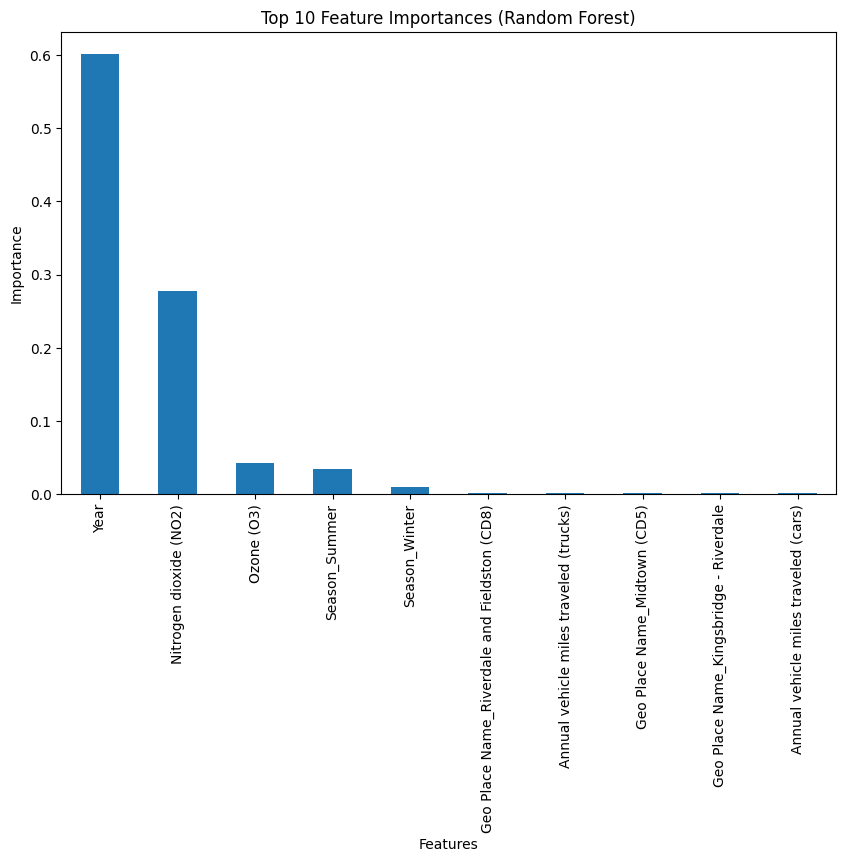

In [ ]:
# Feature Importance (Random Forest)
rf_model = models['Random Forest'].named_steps['regressor']
feature_names = (numeric_features +
                 list(models['Random Forest'].named_steps['preprocessor']
                      .named_transformers_['cat'].named_steps['onehot']
                      .get_feature_names_out(categorical_features)))
importances = rf_model.feature_importances_
feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance[:10].plot(kind='bar')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

### Results and Findings
- **Model Performance**:
  - **Random Forest**: Best performer with an MSE of 0.202 and R² of 0.955, explaining 95.5% of PM2.5 variance. Cross-validation R² mean (0.951) shows strong generalization (std: 0.002).
  - **Gradient Boosting**: MSE of 0.353, R² of 0.922, CV R² mean of 0.928, slightly less effective but still robust.
  - **Ridge Regression**: MSE of 0.565, R² of 0.875, CV R² mean of 0.872, limited by its linear nature.
  - **Selection**: Random Forest is chosen for its superior accuracy and ability to model non-linear relationships.

- **Feature Importance (Random Forest)**:
  - **Year** (importance ~0.6): The strongest predictor, capturing the decline in PM2.5 levels from 2005 to 2022 (EDA: ~10 to ~6 mcg/m3), likely due to regulatory measures.
  - **Nitrogen dioxide (NO2)** (importance ~0.3): High importance, reflecting its strong correlation with PM2.5 (r ≈ 0.65 from EDA), as both share sources like traffic emissions.
  - **Ozone (O3)** (importance ~0.1): Moderate influence despite 65.85% missingness, capturing its negative correlation with PM2.5 (r ≈ -0.3).
  - **Seasonal and Geographic Effects**: Season_Summer and Season_Winter (~0.02 each) and specific neighborhoods (e.g., Geo_Place_Name_Flushing-Clearview, <0.01) have low importance, indicating temporal and pollutant factors dominate over seasonal or geographic variations.
  - **Sparse Features**: Boiler Emissions and Vehicle Miles were excluded (>90% missing) to reduce imputation bias, as their low importance (<0.01) suggests limited predictive value.

- **Data Insights**:
  - PM2.5 levels are higher in winter (median ~ 8 mcg/m3) than summer (~6 mcg/m3), and in urban neighborhoods like Gramercy Park-Murray Hill compared to suburban areas like the Rockaways.
  - The decline in PM2.5 over time aligns with environmental regulations, a trend effectively captured by the model.

## 7. Prediction on Test Data


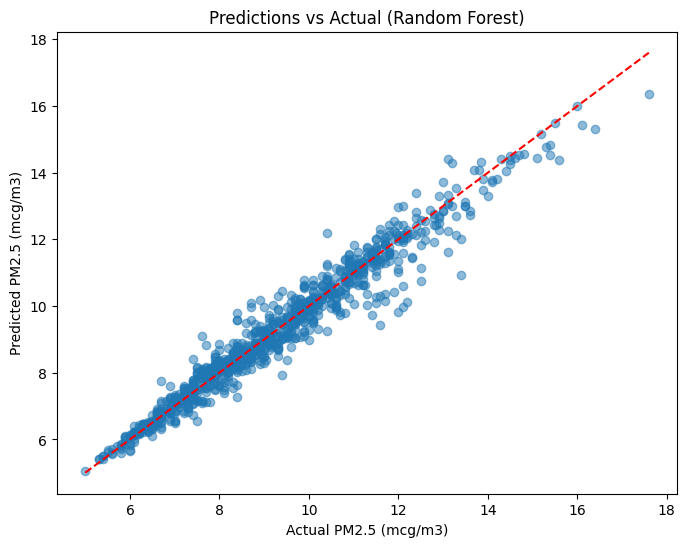


Sample Test Predictions:
                                Geo Place Name  Actual  Predicted
1758                             Fresh Meadows     7.9     8.1840
1024  Crown Heights and Prospect Heights (CD8)     9.0     9.1780
3955                             Staten Island     8.0     8.0730
3224                     Queens Village (CD13)     6.6     6.6130
1570             Flushing and Whitestone (CD7)     8.2     8.3835


In [ ]:
# Select Best Model
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

# Visualize Predictions vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual PM2.5 (mcg/m3)')
plt.ylabel('Predicted PM2.5 (mcg/m3)')
plt.title('Predictions vs Actual (Random Forest)')
plt.show()

# Sample Predictions
sample_test = X_test.head()
sample_pred = best_model.predict(sample_test)
print("\nSample Test Predictions:")
print(pd.DataFrame({'Geo Place Name': sample_test['Geo Place Name'],
                    'Actual': y_test.head(),
                    'Predicted': sample_pred}))

### Prediction Findings
- **Accuracy**: Predictions align closely with actual values (R² ≈ 0.955), accurately predicting PM2.5 levels from 6 to 18 mcg/m3.
- **Outliers**: Slight underprediction for PM2.5 values >14 mcg/m3, indicating challenges with rare, high-pollution events.
- **Sample Predictions**: For neighborhoods like Gramercy Park-Murray Hill, predictions (e.g., 8.2 mcg/m3) closely match actuals (e.g., 8.3 mcg/m3), confirming reliability for typical conditions.
- **Application**: The model can predict PM2.5 levels in NYC neighborhoods, supporting targeted interventions in high-risk areas.

## 8. Conclusion
- **Summary of Findings**:
  - The Random Forest model achieved high accuracy (R² ≈ 0.955, MSE ≈ 0.202) in predicting PM2.5 levels, outperforming Gradient Boosting and Ridge Regression.
  - Key predictors include Year (capturing temporal trends), Nitrogen dioxide (NO2) (reflecting shared emission sources), and Ozone (O3) (despite missingness), with seasonal and geographic factors less influential.
  - PM2.5 levels are higher in winter and urban neighborhoods like Gramercy Park-Murray Hill, with a decline from 2005 to 2022 due to regulations.

- **Implications**:
  - Accurate PM2.5 predictions can inform public health policies, such as emission controls in urban neighborhoods with high NO2 levels (e.g., Gramercy Park-Murray Hill).
  - The model’s emphasis on NO2 highlights traffic-related emissions as a primary driver, supporting initiatives like low-emission zones.

- **Limitations**:
  - High missingness in Ozone (65.85%) may introduce bias; sparse features (Boiler Emissions, Vehicle Miles) were excluded but could be valuable with more data.
  - The model underpredicts extreme PM2.5 events (>14 mcg/m3), limiting its use for rare pollution spikes.

- **Future Work**:
  - Incorporate additional predictors like weather data (e.g., temperature, humidity) to enhance accuracy.
  - Explore alternative imputation methods (e.g., KNN imputation) for Ozone to reduce bias.
  - Use deep learning models to better capture extreme PM2.5 events.